## Exploratory Data Analysis (EXIST 2026 Dataset)

This notebook explores the EXIST 2026 Dataset that focuses on multimedia formats: images (memes) and videos (TikToks). The main focus of the Exist Task is sexism identification.

In [13]:
#Libraries
import json
from pathlib import Path
from collections import Counter
import seaborn as sns
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

os.chdir("/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist/")

In [14]:
#Load Data
df = pd.read_parquet("./data/processed/train_base.parquet")
df.head()

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft,task23_num_hard_labels
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/OiesamamadaOficial www.facebook.com/Ofesamamadaoficial 130 PEROVEOQUE LAS QUE VAN SIGUEN IGUAL DE GORDAS-Y-SE ME PASA,110887.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'3d_eye_states_pupil diameter left [mm]_max': 3.0798, '3d_eye_states_pupil diameter left [mm]_me...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'garmin_hr_max': 68.2535, 'garmin_hr_mean': 65.5112, 'garmin_hr_min': 62.6781, 'garmin_hr_std': ...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'EXG_Channel_0_Alpha_power': -0.6211, 'EXG_Channel_0_Beta_power': -0.4255, 'EXG_Channel_0_Delta_power': -0.53...",1.0,True,1.000000,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 1, 'OBJECTIFICATION': 1, 'SEXUAL-VIOLENCE': 0, 'STEREOTYPING-DOMINANCE': 0}",True,"{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0.5, 'OBJECTIFICATION': 0.6666666666666666, 'SEXUAL-VIOLENCE': 0.0, 'STEREOTYPING-DOMINANCE': 0.16666666666666666}",2
1,110466,es,Se necesita cuidadora para adulto mayor.... fotos del pobre viejo... JAKA,110466.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'3d_eye_states_pupil diameter left [mm]_max': 4.2079, '3d_eye_states_pupil diameter left [mm]_me...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'garmin_hr_max': 61.0, 'garmin_hr_mean': 59.3913, 'garmin_hr_min': 57.0, 'garmin_hr_std': 1.2065...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'EXG_Channel_0_Alpha_power': 0.7818, 'EXG_Channel_0_Beta_power': 1.5039, 'EXG_Channel_0_Delta_power': 0.4666,...",NaN,False,0.500000,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0, 'OBJECTIFICATION': 0, 'SEXUAL-VIOLENCE': 1, 'STEREOTYPING-DOMINANCE': 1}",True,"{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0.16666666666666666, 'OBJECTIFICATION': 0.16666666666666666, 'SEXUAL-VIOLENCE': 0.3333333333333333, 'STEREOTYPING-DO...",2
2,111269,es,tomboy como son el anime y manga pre to tomboy en la vida real,111269.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': None, 'ES2': {'3d_eye_states_pupil diameter left [mm]_max': 4.5193, '3d_eye_states_pupil diameter...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': None, 'ES2': {'garmin_hr_max': 61.0, 'garmin_hr_mean': 60.2, 'garmin_hr_min': 60.0, 'garmin_hr_st...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'EXG_Channel_0_Alpha_power': 0.3173, 'EXG_Channel_0_Beta_power': -0.1913, 'EXG_Channel_0_Delta_power': 0.6395...",1.0,True,0.833333,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0, 'OBJECTIFICATION': 1, 'SEXUAL-VIOLENCE': 0, 'STEREOTYPING-DOMINANCE': 0}",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0.16666666666666666, 'OBJECTIFICATION': 0.6666666666666666, 'SEXUAL-VIOLENCE': 0.16666666666666666, 'STEREOTYPING-DOMINANCE': 0.1666...",1
3,110593,es,"HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ESTE GRUPO COMO TODOS LOS DÍAS SOIS ESPECIALES, FELIZ DÍA DE LA MUJER A TODAS, HUMILDEMENTE, EL ADMINISTRADOR. memegenerator.es",110593.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'3d_eye_states_pupil diameter left [mm]_max': 3.3049, '3d_eye_states_pupil diameter left [mm]_me...","{'EN1': None, 'EN2': None, 'EN3':

In [15]:
#Path to the data
DATA_DIR = os.path.join("data", "memes", "training")
IMAGES_DIR = os.path.join(DATA_DIR, "memes")

## 1. Memes

In [16]:
# #Load the data 
# #Read the JSON file containing the training data
# with open(os.path.join(DATA_DIR, "EXIST2026_training.json"), "r", encoding="utf-8") as f:
#     raw_data = json.load(f)

# # Convert the raw data into a list of records
# records = []
# for key, item in raw_data.items():
#     row = item.copy()
#     records.append(row)

# #Dataframe creation
# df = pd.DataFrame(records)
# print("Shape:", df.shape)
# df.head()


en    2005
es    1979
Name: lang, dtype: int64


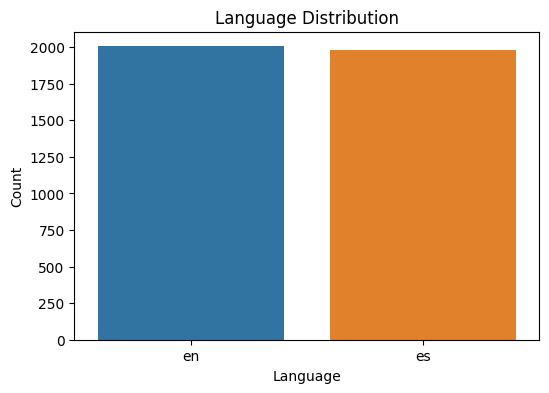

In [17]:
#Language distribution
print(df["lang"].value_counts(dropna=False))
plt.figure(figsize=(6, 4))
sns.barplot(x=df["lang"].value_counts().index, y=df["lang"].value_counts().values)
plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

In [18]:
df["text_length_chars"] = df["text"].fillna("").apply(len)
df["text_length_words"] = df["text"].fillna("").apply(lambda x: len(str(x).split()))
df[["text_length_chars", "text_length_words"]].describe()

,text_length_chars,text_length_words
count,3984.000000,3984.000000
mean,124.300452,21.595382
std,104.717776,18.115024
min,9.000000,2.000000
25%,64.000000,11.000000
50%,96.000000,17.000000
75%,144.000000,26.000000
max,1777.000000,299.000000


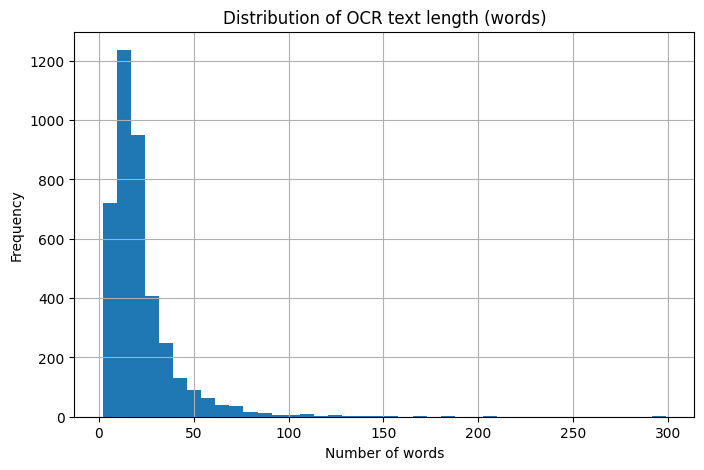

In [19]:
df["text_length_words"].hist(bins=40)
plt.title("Distribution of OCR text length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

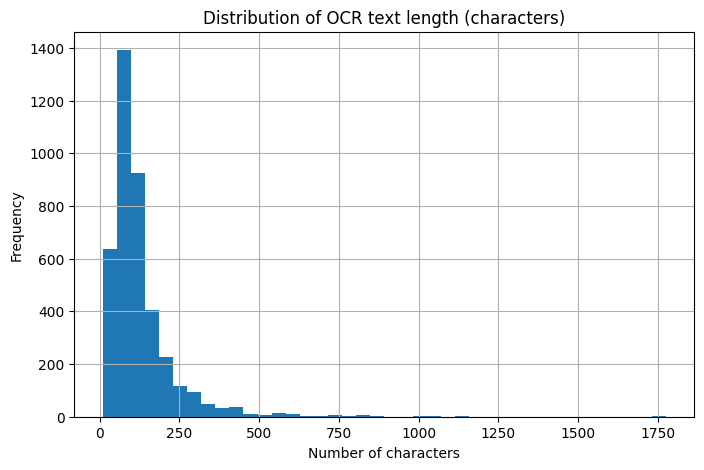

In [20]:
df["text_length_chars"].hist(bins=40)
plt.title("Distribution of OCR text length (characters)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

## Hard Label Distribution

### Task 2.1 Sexism (Yes/No)

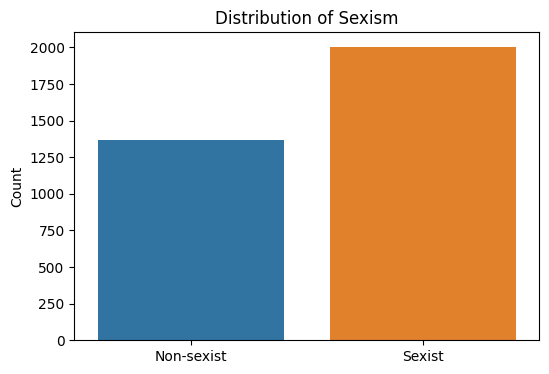

In [21]:
df_task21 = df[df["task21_valid_hard"] == True]

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df_task21["task21_hard"])
plt.title("Distribution of Sexism")
plt.xlabel("")
ax.set_xticklabels(["Non-sexist", "Sexist"])
plt.ylabel("Count")
plt.show()

### Task 2.2 Intention (Judgemental/Direct)

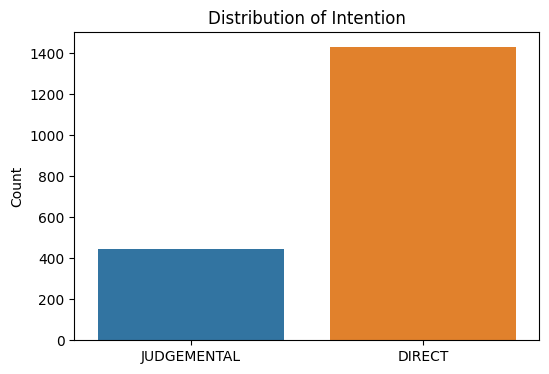

In [22]:

df_task22 = df[df["task22_valid_hard"] == True]

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df_task22["task22_hard"])
plt.title("Distribution of Intention")
plt.xlabel("")
ax.set_xticklabels(["JUDGEMENTAL", "DIRECT"])
plt.ylabel("Count")
plt.show()

### Task 2.3 Sexism Categorization

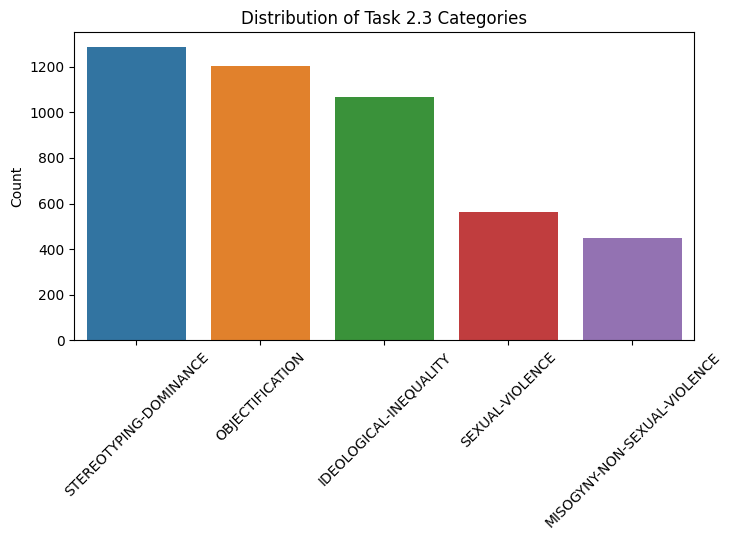

In [23]:
# Filtrar solo los válidos
df_task23 = df[df["task23_valid_hard"] == True]["task23_hard"].apply(pd.Series)
counts = df_task23.sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Distribution of Task 2.3 Categories")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Soft Label Distribution

### Task 2.1 Sexism (Yes/No)

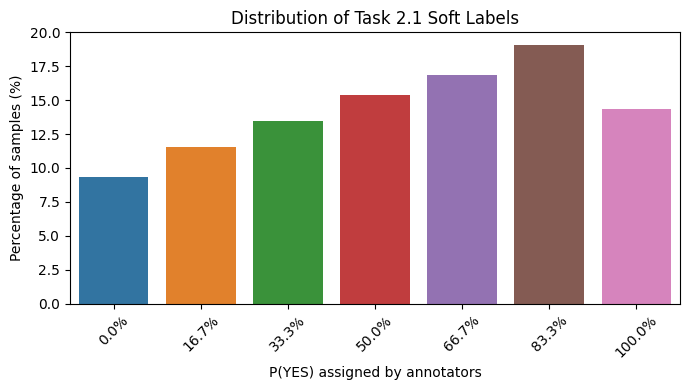

In [24]:
# Distribution of task21_soft values
soft_dist = df["task21_soft"].value_counts(dropna=False).sort_index().reset_index()
soft_dist.columns = ["task21_soft", "count"]
soft_dist["percentage"] = soft_dist["count"] / len(df) * 100

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=soft_dist, x="task21_soft", y="percentage")
ax.set_xticklabels([f"{x*100:.1f}%" for x in soft_dist["task21_soft"]])
ax.set_title("Distribution of Task 2.1 Soft Labels")
ax.set_xlabel("P(YES) assigned by annotators")
ax.set_ylabel("Percentage of samples (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 2.2 Source Intention (Judgemental / Direct)

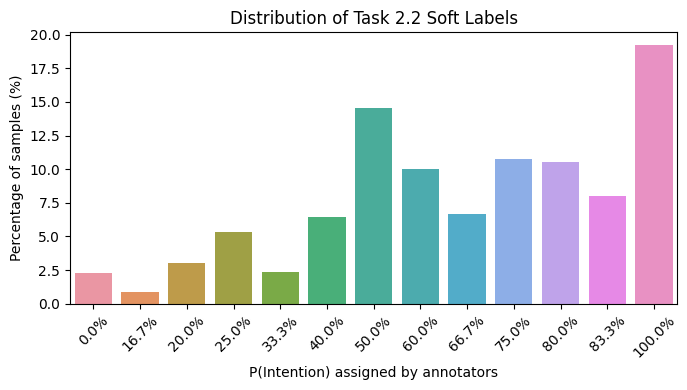

In [25]:
# Distribution of task22_soft values
df_task22_soft = df[df["task21_hard"] == 1]  # We filter only the cases where task21_hard is 1 (sexist).
soft_dist = df_task22_soft["task22_soft"].value_counts(dropna=False).sort_index().reset_index()
soft_dist.columns = ["task22_soft", "count"]
soft_dist["percentage"] = soft_dist["count"] / len(df_task22_soft) * 100

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=soft_dist, x="task22_soft", y="percentage")
ax.set_xticklabels([f"{x*100:.1f}%" for x in soft_dist["task22_soft"]])
ax.set_title("Distribution of Task 2.2 Soft Labels")
ax.set_xlabel("P(Intention) assigned by annotators")
ax.set_ylabel("Percentage of samples (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 2.3 Sexism Categorization (Multilabel)

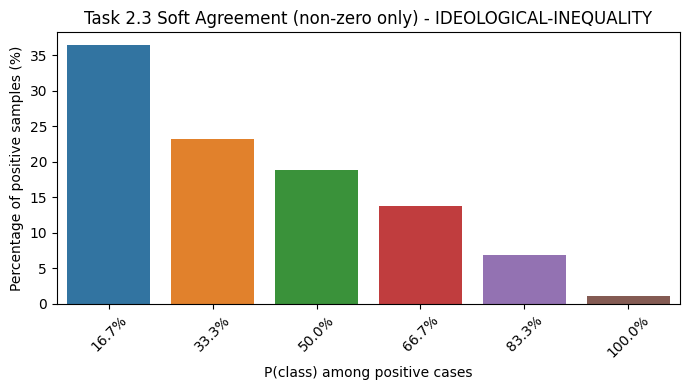

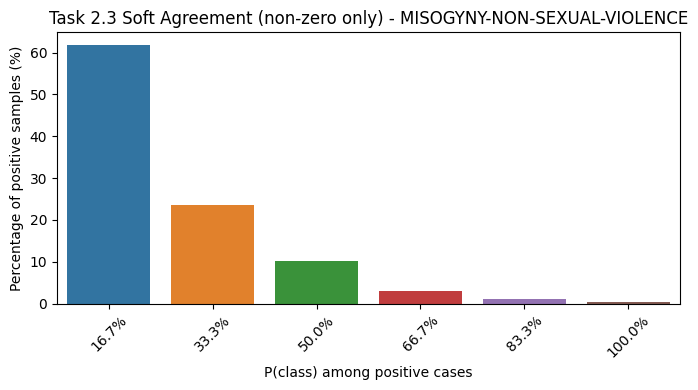

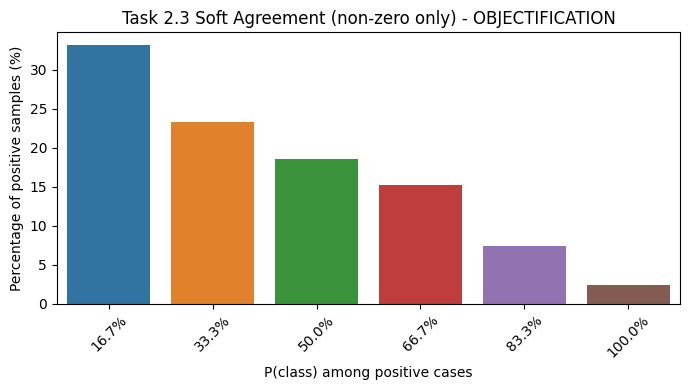

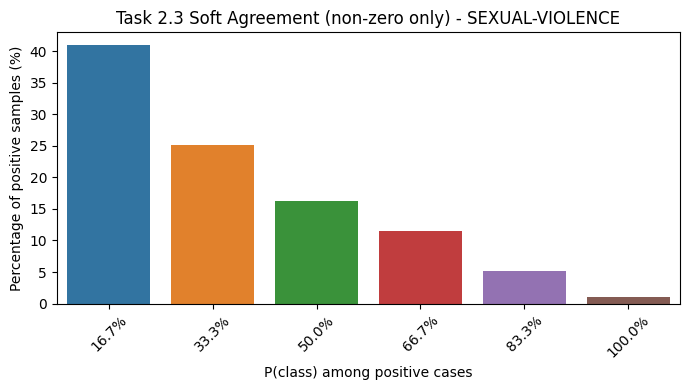

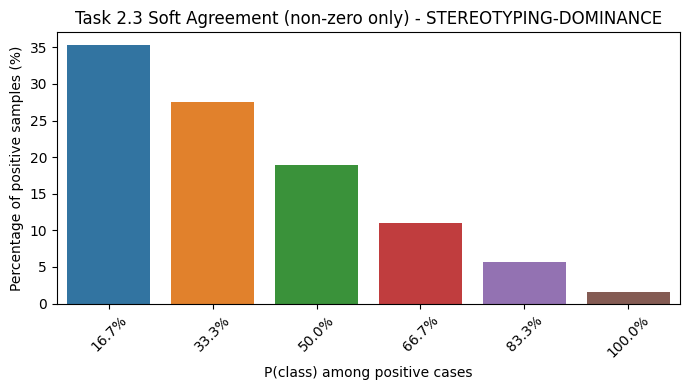

In [26]:
df_task23_soft = df[df["task21_hard"] == 1]["task23_soft"].apply(pd.Series)

for column in df_task23_soft.columns:
    values = df_task23_soft[column].dropna()
    non_zero = values[values > 0]

    if len(non_zero) > 0:
        soft_dist = non_zero.value_counts().sort_index().reset_index()
        soft_dist.columns = ["soft_value", "count"]
        soft_dist["percentage"] = soft_dist["count"] / len(non_zero) * 100

        plt.figure(figsize=(7, 4))
        ax = sns.barplot(data=soft_dist, x="soft_value", y="percentage")
        ax.set_xticklabels([f"{x*100:.1f}%" for x in soft_dist["soft_value"]])
        ax.set_title(f"Task 2.3 Soft Agreement (non-zero only) - {column}")
        ax.set_xlabel("P(class) among positive cases")
        ax.set_ylabel("Percentage of positive samples (%)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

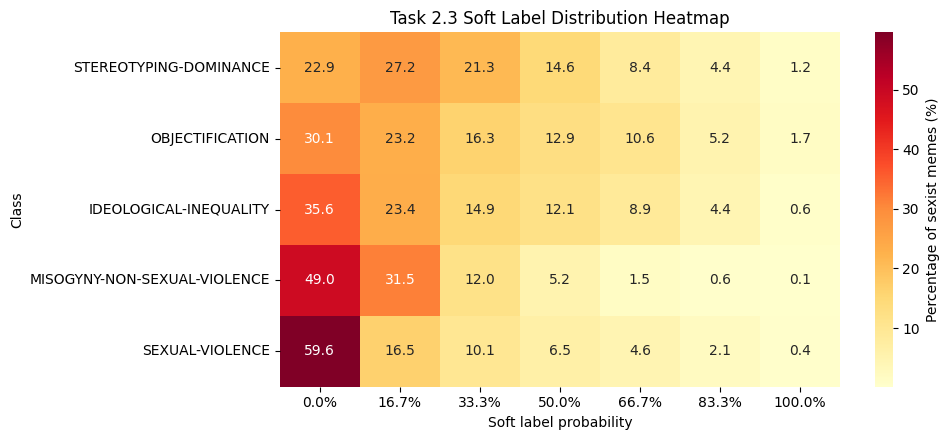

In [27]:
# Build Heatmap (percentage table)
heatmap_rows = []

for column in df_task23_soft.columns:
    values = df_task23_soft[column].dropna()
    dist = values.value_counts(normalize=True).sort_index() * 100
    row = {"class": column}
    for soft_value, pct in dist.items():
        row[soft_value] = pct
    
    heatmap_rows.append(row)

heatmap_df = pd.DataFrame(heatmap_rows).set_index("class")
heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)
heatmap_plot = heatmap_df.fillna(0)
pretty_cols = [f"{c*100:.1f}%" for c in heatmap_plot.columns]
heatmap_plot.columns = pretty_cols

class_prevalence = (df_task23_soft > 0).mean().sort_values(ascending=False)
heatmap_plot = heatmap_plot.loc[class_prevalence.index]

plt.figure(figsize=(10, 4.5))
sns.heatmap(heatmap_plot,annot=True,fmt=".1f",cmap="YlOrRd",cbar_kws={"label": "Percentage of sexist memes (%)"})
plt.title("Task 2.3 Soft Label Distribution Heatmap")
plt.xlabel("Soft label probability")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

### Examples

In [31]:
df.head(1)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft,task23_num_hard_labels,text_length_chars,text_length_words
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/OiesamamadaOficial www.facebook.com/Ofesamamadaoficial 130 PEROVEOQUE LAS QUE VAN SIGUEN IGUAL DE GORDAS-Y-SE ME PASA,110887.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'3d_eye_states_pupil diameter left [mm]_max': 3.0798, '3d_eye_states_pupil diameter left [mm]_me...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'garmin_hr_max': 68.2535, 'garmin_hr_mean': 65.5112, 'garmin_hr_min': 62.6781, 'garmin_hr_std': ...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5': None, 'EN6': None, 'EN7': None, 'ES1': {'EXG_Channel_0_Alpha_power': -0.6211, 'EXG_Channel_0_Beta_power': -0.4255, 'EXG_Channel_0_Delta_power': -0.53...",1.0,True,1.0,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 1, 'OBJECTIFICATION': 1, 'SEXUAL-VIOLENCE': 0, 'STEREOTYPING-DOMINANCE': 0}",True,"{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666, 'MISOGYNY-NON-SEXUAL-VIOLENCE': 0.5, 'OBJECTIFICATION': 0.6666666666666666, 'SEXUAL-VIOLENCE': 0.0, 'STEREOTYPING-DOMINANCE': 0.16666666666666666}",2,162,16


In [71]:
def load_meme_image(row, images_dir=IMAGES_DIR):
    img_path = os.path.join(images_dir, row["image_file"])
    if img_path is None:
        print(f"Image path is None for row: {row['id']}")
        return None
    return Image.open(img_path)

def show_meme(row, images_dir=IMAGES_DIR, figsize=(8, 8)):
    img = load_meme_image(row, images_dir=images_dir)
    if img is None:
        return
    
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    sexist = {0:"Non-sexist", 1:"Sexist"}.get(row.get("task21_hard"), "Unknown")
    intention = {0:"JUDGEMENTAL", 1:"DIRECT"}.get(row.get("task22_hard"), "Not Applicable")
    plt.title(f'id={row["id"]} | lang={row["lang"]}\n Sexist={sexist} | Intention={intention} | Agreement={row.get("task21_soft", None):.2f}')
    plt.show()

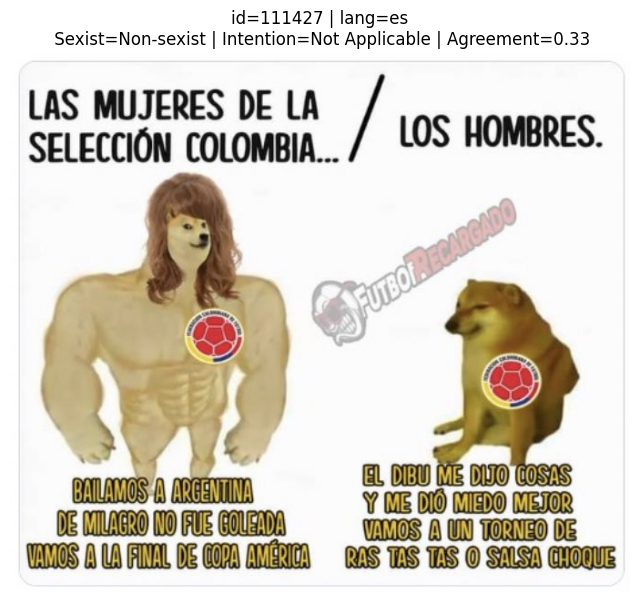

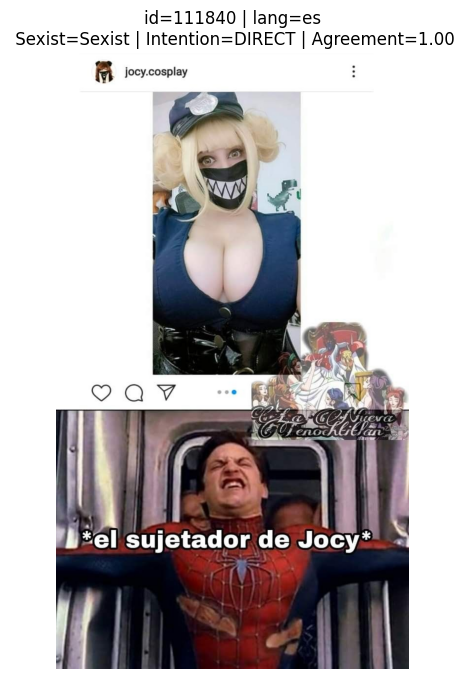

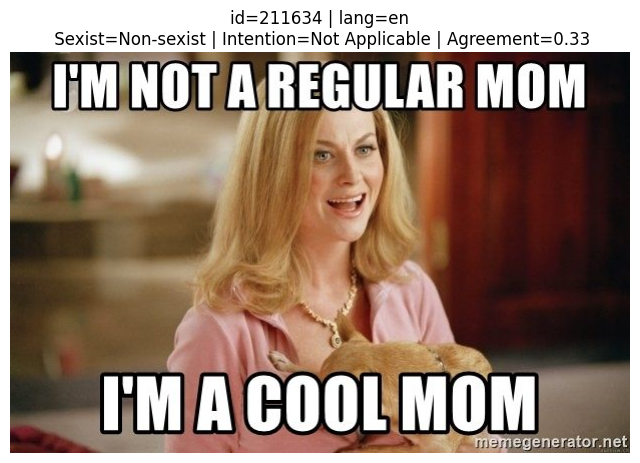

In [72]:
sample_rows = df.sample(3, random_state=123)
for _, row in sample_rows.iterrows():
    show_meme(row)

In [73]:
df.columns

Index(['id', 'lang', 'text', 'image_file', 'split', 'ET_raw', 'HR_raw',
       'EEG_raw', 'task21_hard', 'task21_valid_hard', 'task21_soft',
       'task22_hard', 'task22_valid_hard', 'task22_soft', 'task23_hard',
       'task23_valid_hard', 'task23_soft', 'task23_num_hard_labels',
       'text_length_chars', 'text_length_words'],
      dtype='object')

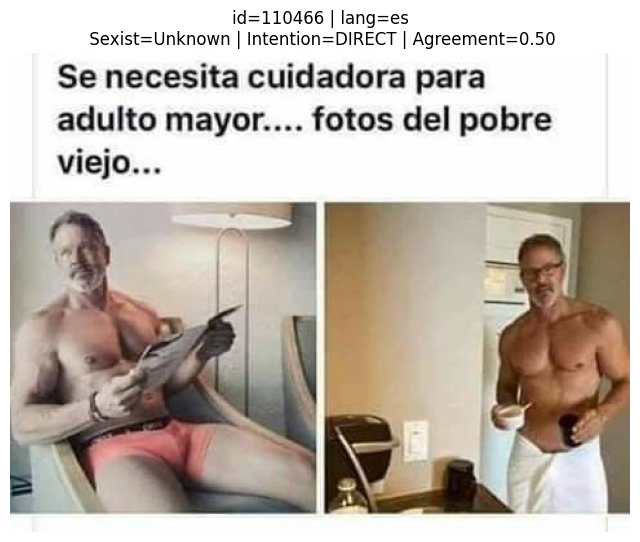

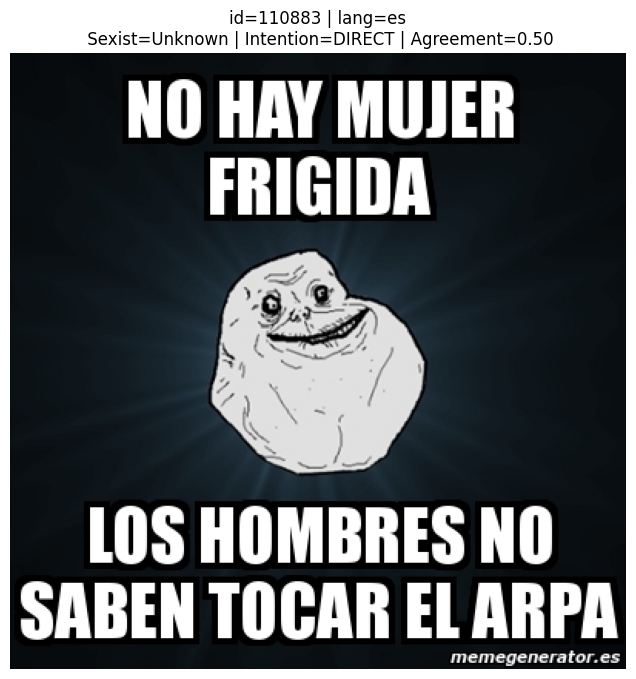

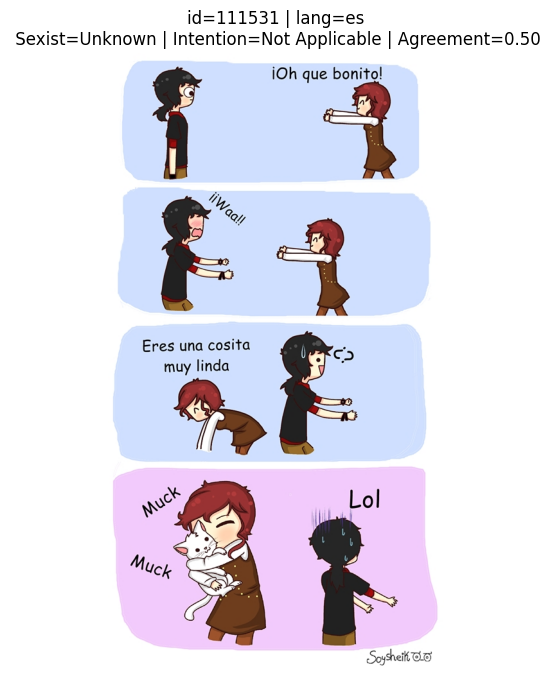

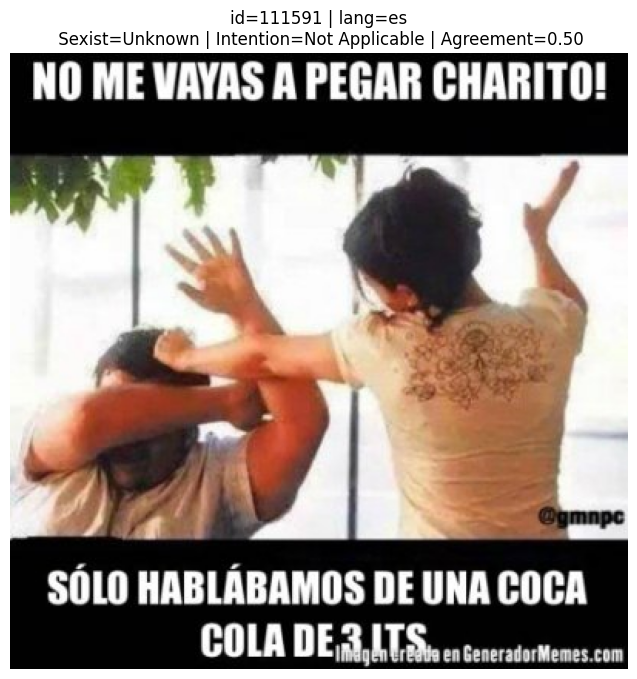

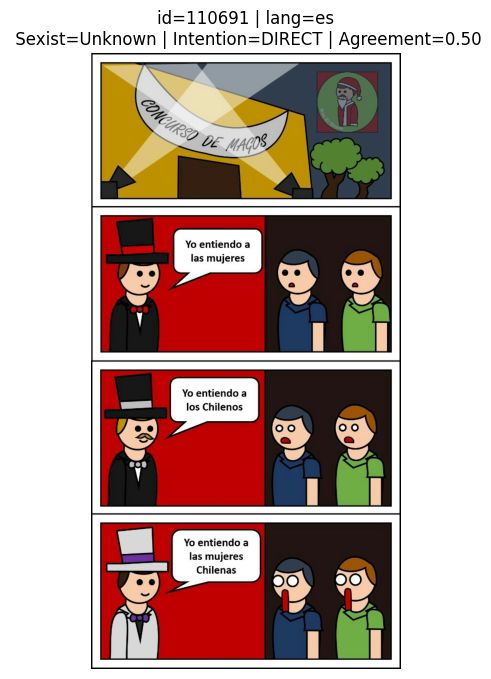

In [76]:
# Ambiguous cases with low agreement
ambiguous = df[df["task21_soft"]==0.5].head(5)
for _, row in ambiguous.iterrows():
    show_meme(row)